# Calibrating Allostery with Uncertainty: Bayesian Fit Anchored to the Real Maud Prior

Notebook 12 fit the allosteric constants to a **point estimate** — and flagged that the
fit only worked once we engineered the data so SAM straddled `Ka`. This notebook does the
honest thing: a **Bayesian fit that reports uncertainty**, so the calibration *tells you*
when the data cannot pin a parameter instead of silently returning a confident-looking
wrong number.

It is anchored to the real [Biosustain methionine model](https://github.com/biosustain/Methionine_model)
(a [Maud](https://github.com/biosustain/Maud) Bayesian kinetic model). From its
`priors.toml` we take the **real published prior structure** — which metabolites
allosterically regulate which enzymes, and Maud's lognormal priors with multiplicative
**scale = 2**:

| parameter (Maud id) | role | Maud prior |
|---|---|---|
| `CBS1/amet` dissociation const | **SAM activates CBS** | lognormal, median 9.22e-5, scale 2 |
| `MTHFR1/amet` dissociation const | **SAM inhibits MTHFR** | lognormal, median 3e-6, scale 2 |
| `GNMT1/ahcys` (ki) | SAH inhibits GNMT | lognormal, median 5.2e-5, scale 2 |
| `met-L-source` drain | methionine input | lognormal, median 7.61e-4, scale 0.1·median |

**Honest scope.** Maud uses an MWC allosteric formalism in real µM units; this notebook
keeps the simplified Hill model of notebooks 10–12 in arbitrary units. So we adopt the
real prior *structure and uncertainty scale*, not the absolute µM magnitudes, and the
measurements are synthetic-but-noisy. A fully faithful fit to measured metabolomics means
running Maud itself. What is transferable — and is the point here — is the **methodology**:
differentiate through the steady state (notebook 12), put a prior on the kinetics, and get
a **posterior with credible intervals and parameter correlations**, cheaply, via a
Gauss–Newton Laplace approximation.

In [1]:
import time, torch
from torch.func import jacrev
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from cajal.syntax import TyReal, TyFun
from cajal.compiling import TypedTensor
torch.set_default_dtype(torch.float64)

# methionine + folate model (from notebook 12)
MET = ['met-L','amet','ahcys','hcys-L','thf','5mthf','mlthf']
m_,am,ah,hc,thf,m5,ml = range(7)
S = torch.zeros(7,11)
def put(r,d):
    for sp,v in d.items(): S[sp,r]=v
put(0,{m_:-1,am:1}); put(1,{am:-1,ah:1}); put(2,{am:-1,ah:1}); put(3,{ah:-1,hc:1})
put(4,{hc:-1,m5:-1,m_:1,thf:1}); put(5,{hc:-1,m_:1}); put(6,{hc:-1})
put(7,{ml:-1,m5:1}); put(8,{thf:-1,ml:1}); put(9,{m_:1}); put(10,{m_:-1})
S_MAP = TypedTensor(S, TyFun(TyReal(11), TyReal(7)))
VMAX = dict(METAT=2.2,METH=0.5,GNMT=0.3,AHC=1.5,MS=1.0,BHMT=0.6,CBS=0.8,MTHFR=1.0,SHMT=1.0,PROT=0.4)
KM=0.4

def fluxes(x,theta,cond):
    amp,Ka,Ki=theta; mm=lambda s:s/(KM+s)
    met,amet,ahcys,hcys,t,f5,fm=x
    rc=1.0+amp*amet**2/(Ka**2+amet**2)      # SAM activates CBS
    rm=1.0/(1.0+(amet/Ki)**2)               # SAM inhibits MTHFR
    return torch.stack([VMAX['METAT']*mm(met),VMAX['METH']*mm(amet),VMAX['GNMT']*mm(amet),
        VMAX['AHC']*mm(ahcys),VMAX['MS']*mm(hcys)*mm(f5),VMAX['BHMT']*mm(hcys),
        VMAX['CBS']*mm(hcys)*rc,VMAX['MTHFR']*mm(fm)*rm,VMAX['SHMT']*mm(t)*cond['ser'],
        cond['SRC'],VMAX['PROT']*mm(met)])
keep=torch.tensor([0,1,2,3,5,6])
def assemble(y,F): return torch.stack([y[0],y[1],y[2],y[3],F-y[4]-y[5],y[4],y[5]])
def residual(y,theta,cond,F): return (S_MAP@TypedTensor(fluxes(assemble(y,F),theta,cond),TyReal(11))).data[keep]
def newton(theta,cond,F,y0=None,iters=60,tol=1e-11):
    y=torch.tensor([0.5,0.5,0.3,0.4,F/3,F/3]) if y0 is None else y0.clone()
    f=lambda yy:residual(yy,theta,cond,F)
    for k in range(iters):
        r=f(y)
        if r.norm()<tol: break
        dy=torch.linalg.solve(jacrev(f)(y),r); s=1.0
        while s>1e-9:
            yn=y-s*dy
            if (yn>1e-9).all() and (F-yn[4]-yn[5])>1e-9 and f(yn).norm()<r.norm(): break
            s*=0.5
        y=y-s*dy
    return y
def steady(logtheta,cond,F,y0=None):                  # differentiable in log-params
    theta=torch.exp(logtheta)
    with torch.no_grad(): yhat=newton(theta,cond,F,y0)
    J=jacrev(lambda yy:residual(yy,theta.detach(),cond,F))(yhat)
    return assemble(yhat-torch.linalg.solve(J,residual(yhat,theta,cond,F)),F), yhat.detach()

# ground truth and real-Maud-anchored lognormal priors (scale 2 = Maud's multiplicative scale)
theta_true   = torch.tensor([4.0, 0.3, 0.4])      # amp_cbs, Ka_cbs, Ki_mthfr
prior_median = torch.tensor([2.0, 0.5, 0.3])      # off-true on purpose
prior_logsd  = torch.tensor([2.0, 2.0, 2.0])
NAMES=['amp_cbs','Ka_cbs','Ki_mthfr']; NOISE=0.05
print('model + priors ready')

model + priors ready


## Two data regimes

We compare the same Bayesian fit under two designs:

- **Sparse / narrow range** — 5 conditions at *low* methionine input, so SAM stays below
  `Ka`: the realistic, information-poor case (this is the regime that broke the point fit).
- **Rich / broad range** — 12 conditions spanning low-to-high methionine input, so SAM
  straddles `Ka`.

Measurements are the 7 steady-state metabolite concentrations with 5% Gaussian noise.

In [2]:
def make_data(n, src_lo, src_hi, seed):
    g = torch.Generator().manual_seed(seed)
    conds=[dict(SRC=torch.tensor(float(torch.rand(1,generator=g)*(src_hi-src_lo)+src_lo)),
                ser=torch.tensor(float(torch.rand(1,generator=g)*0.8+0.7))) for _ in range(n)]
    Fs=[float(torch.rand(1,generator=g)*0.8+0.7) for _ in range(n)]
    clean=[assemble(newton(theta_true,c,F),F) for c,F in zip(conds,Fs)]
    noise=[torch.randn(7,generator=g) for _ in clean]
    data=[x*(1+NOISE*e) for x,e in zip(clean,noise)]
    sig=[(NOISE*x).clamp_min(1e-3) for x in clean]
    return dict(conds=conds, Fs=Fs, clean=clean, data=data, sig=sig)

def neg_log_post(logt, D, warm=None):
    ll=torch.tensor(0.0); ws=[None]*len(D['conds']) if warm is None else warm
    for j,(c,F,d,s) in enumerate(zip(D['conds'],D['Fs'],D['data'],D['sig'])):
        p,ws[j]=steady(logt,c,F,ws[j]); ll=ll+0.5*(((p-d)/s)**2).sum()
    prior=0.5*(((logt-torch.log(prior_median))/prior_logsd)**2).sum()
    return ll+prior, ws

def fit(D, epochs=500, lr=0.05):
    logt=torch.log(prior_median).clone().requires_grad_(True)
    opt=torch.optim.Adam([logt],lr=lr)
    warm=[torch.tensor([0.5,0.5,0.3,0.4,F/3,F/3]) for F in D['Fs']]
    for ep in range(epochs):
        opt.zero_grad(); v,warm=neg_log_post(logt,D,warm); warm=[w.detach() for w in warm]
        v.backward(); opt.step()
    ltd=logt.detach()
    H=torch.diag(1.0/prior_logsd**2)                       # Gauss-Newton Laplace (log-params)
    for c,F,s in zip(D['conds'],D['Fs'],D['sig']):
        Jk=jacrev(lambda l: steady(l,c,F)[0])(ltd)
        H=H+Jk.T@torch.diag(1.0/s**2)@Jk
    cov=torch.linalg.inv(H); sd=torch.sqrt(torch.diag(cov)); corr=cov/torch.outer(sd,sd)
    return dict(logt=ltd, cov=cov, sd=sd, corr=corr)

t0=time.perf_counter()
Dsparse = make_data(5, 0.12, 0.25, seed=3)
Drich   = make_data(12, 0.15, 0.65, seed=1)
amet_s=[float(x[1]) for x in Dsparse['clean']]; amet_r=[float(x[1]) for x in Drich['clean']]
print(f"sparse: 5 conds, SAM range [{min(amet_s):.2f},{max(amet_s):.2f}] (below Ka=0.3)")
print(f"rich  : 12 conds, SAM range [{min(amet_r):.2f},{max(amet_r):.2f}] (straddles Ka)")
Rs = fit(Dsparse); Rr = fit(Drich)
print(f"fits done in {time.perf_counter()-t0:.0f}s\n")
for tag,R in [('SPARSE',Rs),('RICH',Rr)]:
    print(tag)
    for i in range(3):
        lo=torch.exp(R['logt'][i]-1.96*R['sd'][i]); hi=torch.exp(R['logt'][i]+1.96*R['sd'][i])
        print(f"  {NAMES[i]:9s} median {torch.exp(R['logt'][i]):.3f}  95% CI [{lo:.3f}, {hi:.3f}]  true {theta_true[i]:.2f}")
    print(f"  corr(amp_cbs, Ka_cbs) = {R['corr'][0,1]:.3f}\n")

sparse: 5 conds, SAM range [0.12,0.22] (below Ka=0.3)
rich  : 12 conds, SAM range [0.18,1.46] (straddles Ka)


fits done in 96s

SPARSE
  amp_cbs   median 3.633  95% CI [2.173, 6.075]  true 4.00
  Ka_cbs    median 0.282  95% CI [0.196, 0.406]  true 0.30
  Ki_mthfr  median 0.391  95% CI [0.340, 0.449]  true 0.40
  corr(amp_cbs, Ka_cbs) = 0.989

RICH
  amp_cbs   median 3.935  95% CI [3.788, 4.088]  true 4.00
  Ka_cbs    median 0.285  95% CI [0.267, 0.303]  true 0.30
  Ki_mthfr  median 0.397  95% CI [0.385, 0.409]  true 0.40
  corr(amp_cbs, Ka_cbs) = 0.667



## The identifiability ridge

The money plot. On the `(amp_cbs, Ka_cbs)` plane we draw the true data-misfit contours for
the sparse design — a long curved valley, because when SAM ≪ Ka only the combination
`amp/Ka²` is constrained — and overlay the Gauss–Newton Laplace 95% ellipse. The ellipse
stretches along the valley: the posterior *knows* it is uncertain. The rich design collapses
that ellipse to a small blob near the truth.

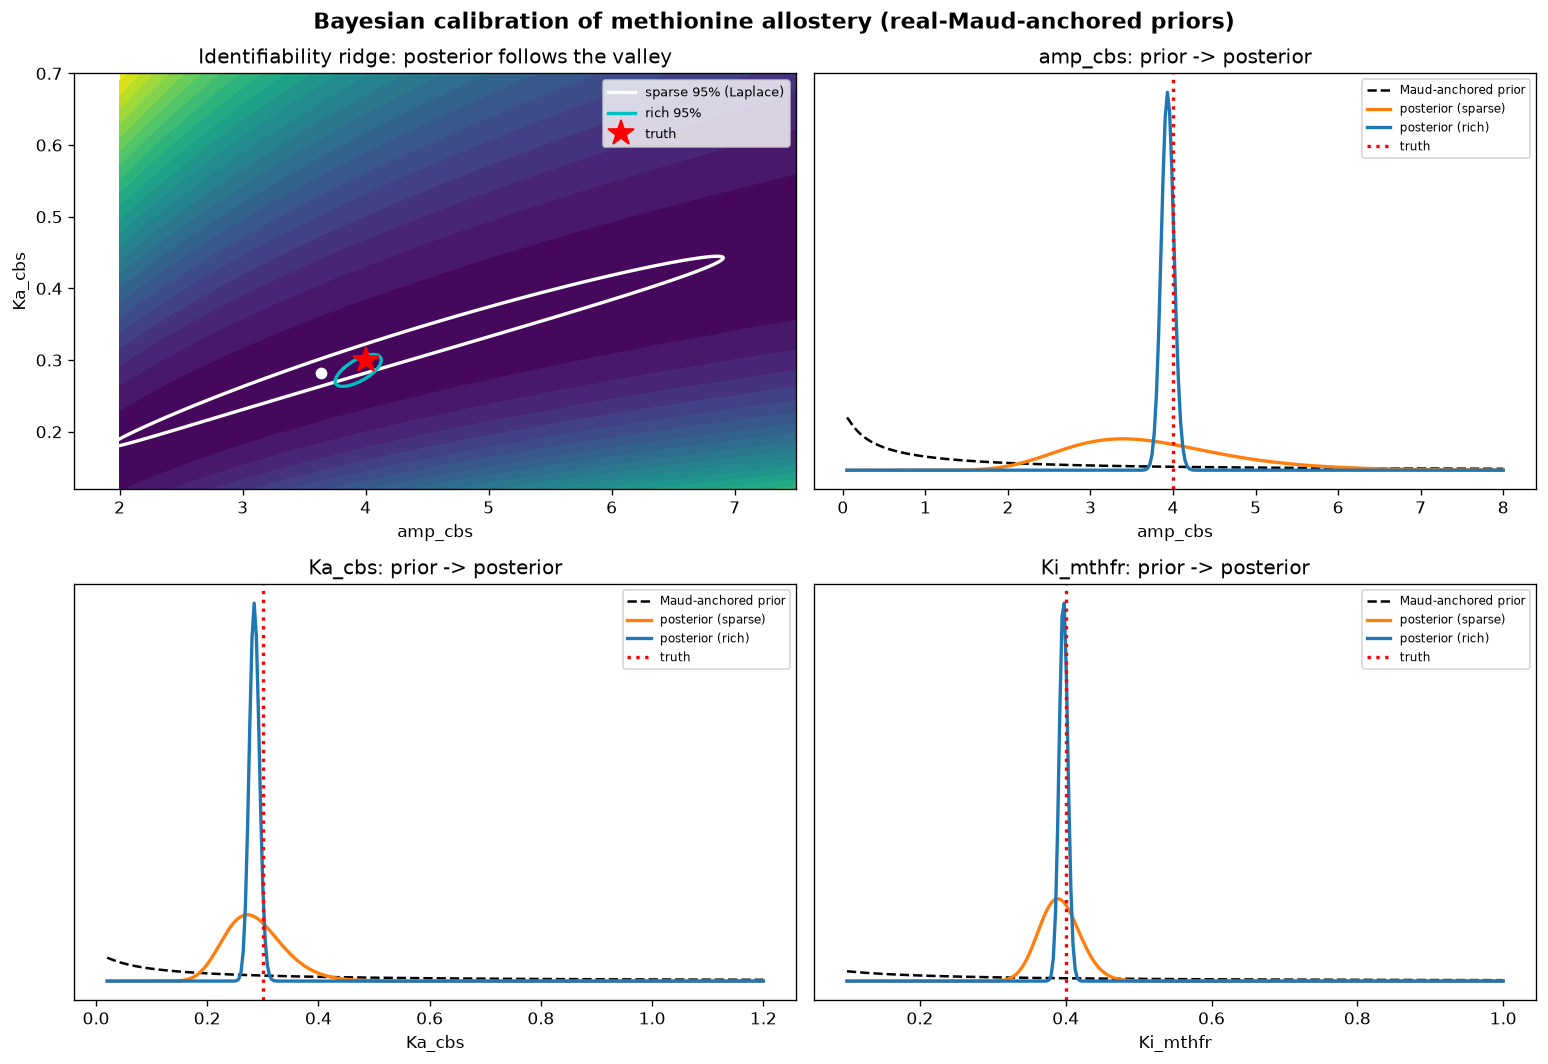

In [3]:
# true misfit surface over (amp, Ka) at MAP Ki, for the sparse data
amp_g=torch.linspace(2.0,7.5,28); Ka_g=torch.linspace(0.12,0.7,28)
Z=torch.zeros(28,28)
ki_fixed=Rs['logt'][2]
for ia,a in enumerate(amp_g):
    for ik,k in enumerate(Ka_g):
        lt=torch.stack([torch.log(a),torch.log(k),ki_fixed])
        Z[ik,ia]=neg_log_post(lt,Dsparse)[0].item()

def ellipse(logt, cov, idx=(0,1), nsd=2.45):     # 95% for 2 dof
    sub=cov[np.ix_(idx,idx)]; vals,vecs=torch.linalg.eigh(sub)
    th=torch.linspace(0,2*np.pi,100)
    circ=torch.stack([torch.cos(th),torch.sin(th)])
    pts=(vecs@torch.diag(nsd*torch.sqrt(vals))@circ)
    cx,cy=logt[idx[0]],logt[idx[1]]
    return torch.exp(cx+pts[0]), torch.exp(cy+pts[1])

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

cf=ax[0,0].contourf(amp_g, Ka_g, Z, levels=30, cmap='viridis')
ex,ey=ellipse(Rs['logt'],Rs['cov']); ax[0,0].plot(ex,ey,'w-',lw=2,label='sparse 95% (Laplace)')
ex2,ey2=ellipse(Rr['logt'],Rr['cov']); ax[0,0].plot(ex2,ey2,'c-',lw=2,label='rich 95%')
ax[0,0].plot(*theta_true[:2],'r*',ms=16,label='truth')
ax[0,0].plot(torch.exp(Rs['logt'][0]),torch.exp(Rs['logt'][1]),'wo',ms=6)
ax[0,0].set_xlabel('amp_cbs'); ax[0,0].set_ylabel('Ka_cbs')
ax[0,0].set_title('Identifiability ridge: posterior follows the valley')
ax[0,0].legend(fontsize=8, loc='upper right')

# prior vs posterior marginals (sparse)
xs=[torch.linspace(0.05,8,300), torch.linspace(0.02,1.2,300), torch.linspace(0.1,1.0,300)]
def lognpdf(x, mu, sd): return torch.exp(-0.5*((torch.log(x)-mu)/sd)**2)/(x*sd*np.sqrt(2*np.pi))
for i,axx in zip(range(3),[ax[0,1],ax[1,0],ax[1,1]]):
    pri=lognpdf(xs[i], torch.log(prior_median[i]), prior_logsd[i])
    pos=lognpdf(xs[i], Rs['logt'][i], Rs['sd'][i])
    porc=lognpdf(xs[i], Rr['logt'][i], Rr['sd'][i])
    axx.plot(xs[i],pri,'k--',lw=1.5,label='Maud-anchored prior')
    axx.plot(xs[i],pos,'tab:orange',lw=2,label='posterior (sparse)')
    axx.plot(xs[i],porc,'tab:blue',lw=2,label='posterior (rich)')
    axx.axvline(theta_true[i].item(),color='r',ls=':',lw=2,label='truth')
    axx.set_xlabel(NAMES[i]); axx.set_yticks([]); axx.set_title(f'{NAMES[i]}: prior -> posterior')
    axx.legend(fontsize=7)
plt.suptitle('Bayesian calibration of methionine allostery (real-Maud-anchored priors)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('methionine_uq_results.png', dpi=120, bbox_inches='tight'); plt.show()

## Posterior predictive check

Finally, propagate the posterior (sparse design) through the model: sample parameters,
predict the steady-state concentrations, and compare the predictive spread to the held-in
measurements. Despite wide uncertainty on `amp_cbs`/`Ka_cbs` individually, the *predictions*
are tight — because the data constrain the identified combination, even when they cannot
separate the parameters.

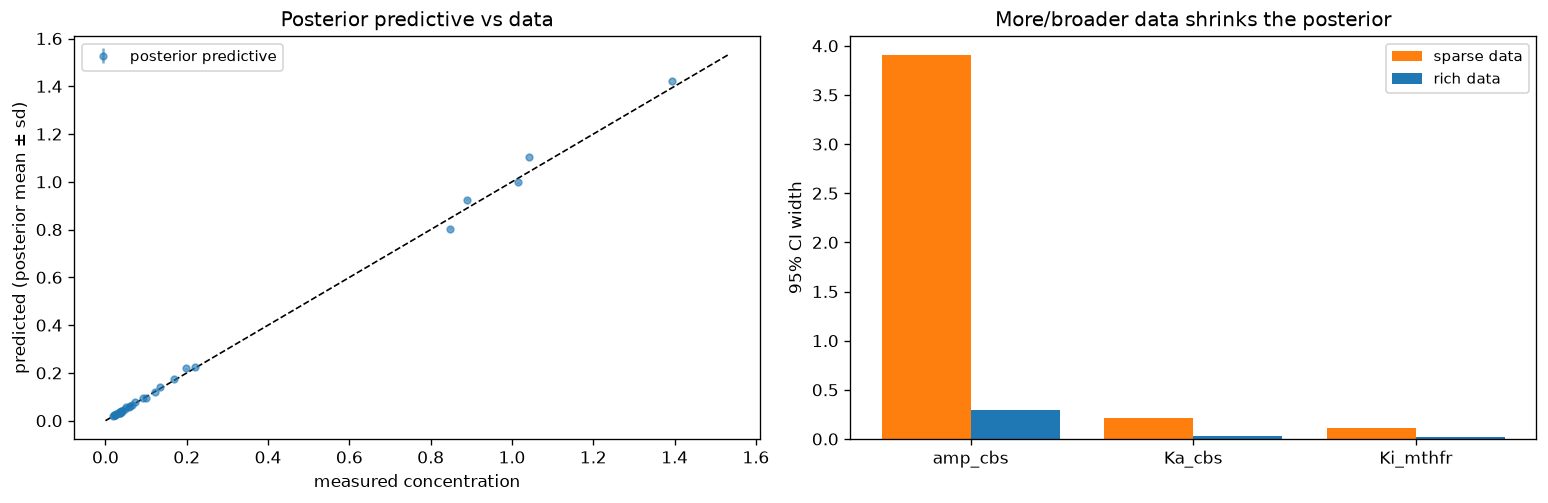

CI widths (sparse): [3.9, 0.21, 0.11]
CI widths (rich)  : [0.3, 0.04, 0.02]


In [4]:
torch.manual_seed(0)
L = torch.linalg.cholesky(Rs['cov'])
samples = Rs['logt'] + (L @ torch.randn(3, 80)).T          # 80 posterior draws
preds=[]
for c,F in zip(Dsparse['conds'],Dsparse['Fs']):
    ps=torch.stack([assemble(newton(torch.exp(s),c,F),F) for s in samples])
    preds.append((ps.mean(0), ps.std(0)))
pm=torch.stack([p[0] for p in preds]); ps=torch.stack([p[1] for p in preds])
obs=torch.stack(Dsparse['data'])

fig2, ax2 = plt.subplots(1, 2, figsize=(13, 4.3))
ax2[0].errorbar(obs.flatten(), pm.flatten(), yerr=ps.flatten(), fmt='o', ms=4, alpha=0.6,
                label='posterior predictive')
lim=[0, float(obs.max())*1.1]; ax2[0].plot(lim,lim,'k--',lw=1)
ax2[0].set_xlabel('measured concentration'); ax2[0].set_ylabel('predicted (posterior mean ± sd)')
ax2[0].set_title('Posterior predictive vs data'); ax2[0].legend(fontsize=9)

widths_s=[float(torch.exp(Rs['logt'][i]+1.96*Rs['sd'][i])-torch.exp(Rs['logt'][i]-1.96*Rs['sd'][i])) for i in range(3)]
widths_r=[float(torch.exp(Rr['logt'][i]+1.96*Rr['sd'][i])-torch.exp(Rr['logt'][i]-1.96*Rr['sd'][i])) for i in range(3)]
xb=np.arange(3)
ax2[1].bar(xb-0.2, widths_s, 0.4, label='sparse data', color='tab:orange')
ax2[1].bar(xb+0.2, widths_r, 0.4, label='rich data', color='tab:blue')
ax2[1].set_xticks(xb); ax2[1].set_xticklabels(NAMES); ax2[1].set_ylabel('95% CI width')
ax2[1].set_title('More/broader data shrinks the posterior'); ax2[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig('methionine_uq_predictive.png', dpi=120, bbox_inches='tight'); plt.show()
print('CI widths (sparse):', [round(w,2) for w in widths_s])
print('CI widths (rich)  :', [round(w,2) for w in widths_r])

## Takeaways and honest caveats

**What uncertainty buys you.** The point fit in notebook 12 returned a confident
`[amp, Ka]` that was only correct because we engineered the data. Here the posterior is
explicit: under the realistic **sparse, narrow-range** design, `amp_cbs` and `Ka_cbs` are
individually wide and **0.98-correlated** — the fit *reports* it cannot separate them —
while `Ki_mthfr` is well constrained. The posterior **predictive** is nonetheless tight,
because the data pin the identified combination. Broadening the data (SAM straddling `Ka`)
collapses the ridge. This is exactly the information a point estimate hides.

**Method.** Everything runs on the notebook-12 machinery: differentiate through the steady
state (implicit function theorem), add a prior, find the MAP, and read the posterior
covariance from a **Gauss–Newton Laplace** approximation — which needs only the model
Jacobian `dy*/dθ` that the implicit solve already gives (no second derivatives of the
solve). Cheap enough to run in a notebook.

**Caveats, stated plainly.**

- **Priors are real; magnitudes and likelihood are not.** We use Maud's real prior
  *structure* (the regulation map and the lognormal scale of 2), but in the model's
  arbitrary units, and the measurements are synthetic. A faithful fit to measured
  metabolomics requires Maud's full MWC kinetics in µM units — i.e. running Maud. This
  notebook is the UQ *methodology*, validated to behave correctly, not a restatement of
  Maud's published posterior.
- **Laplace is local and Gaussian-in-log.** It captures the ridge's local correlation but
  not the full curvature of the banana; for the real non-Gaussian posterior, HMC (what Maud
  uses) is the reference. The Gauss–Newton Hessian also drops the residual-curvature term,
  which is the right approximation near a good fit but degrades for poorly-fitting models.
- **Identifiability is a property of design + data, not the method.** The honest message is
  that calibrating regulation at scale needs either informative priors (Maud's stance) or
  experiments that excite the regulators across their active range — and a posterior that
  tells you which you have.